In [17]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import datetime

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [ ]:
def generate_simulated_data(n_units=10000, n_obs=100, seed=42):
    """Generates synthetic HBMNL choice data with known ground truth parameters."""
    np.random.seed(seed)
    
    n_alts = 4
    n_params = 4  # 3 brand intercepts (alt 0 is base) + 1 price coefficient
    n_demos = 2   # 1 intercept + 1 continuous demographic
    
    # 1. Simulate Demographics (Z matrix)
    Z = np.column_stack([
        np.ones(n_units),                 # Intercept
        np.random.normal(0, 1, n_units)   # Centered continuous demographic (e.g., Income)
    ])
    
    # 2. Define TRUE Global Parameters (Delta)
    # Row 0: Base utilities for Brand 1, Brand 2, Brand 3, and Base Price Sensitivity
    # Row 1: How Demo 1 shifts preferences for those brands and price
    Delta_true = np.array([
        [ 1.5,  0.5, -0.5, -2.0],  
        [ 0.8, -0.3,  0.0,  0.5]   
    ])
    
    # 3. Define TRUE Covariance (Sigma)
    # Moderate variance for intercepts, tight variance for price sensitivity
    Sigma_true = np.diag([0.6, 0.4, 0.5, 0.1]) 
    
    # 4. Generate True Unit-Level Betas
    beta_true = np.zeros((n_units, n_params))
    for i in range(n_units):
        mu_i = Z[i] @ Delta_true
        beta_true[i] = np.random.multivariate_normal(mu_i, Sigma_true)
        
    # 5. Generate Choice Data
    X_list, y_list, unit_idx_list = [], [], []
    
    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            
            # Alternative-specific constants (Alt 0 is reference, so it stays 0)
            X_it[1, 0] = 1.0
            X_it[2, 1] = 1.0
            X_it[3, 2] = 1.0
            
            # Simulated continuous feature (e.g., Price)
            X_it[:, 3] = np.random.uniform(1.0, 5.0, n_alts)
            
            # Calculate Utility and Probabilities
            U_it = X_it @ beta_true[i]
            probs = np.exp(U_it) / np.sum(np.exp(U_it))
            
            # Simulate Choice
            y_it = np.random.choice(n_alts, p=probs)
            
            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)
            
    data_dict = {
        "X": jnp.array(np.array(X_list)),
        "y": jnp.array(np.array(y_list)),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(np.array(unit_idx_list)),
        "n_units": n_units,
        "n_params": n_params,
        "n_alts": n_alts,
        "TRUE_DELTA": Delta_true,
        "TRUE_SIGMA": Sigma_true,
        "TRUE_BETA": beta_true
    }
    
    print(f"Simulated {n_units} units making {n_obs} choices each.")
    print(f"Shape of X: {data_dict['X'].shape}, Shape of Z: {data_dict['Z'].shape}")
    return data_dict

# Generate the data
data_sim = generate_simulated_data()

Simulated 10000 units making 100 choices each.
Shape of X: (1000000, 4, 4), Shape of Z: (10000, 2)


In [19]:
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(df=df, scale_tril=scale_tril, input_output_cholesky=True, validate_args=False)

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc, precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor), validate_args=False
    )

def build_unified_hmnl_model(data_dict, A_val=0.01):
    k_dim = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    has_Z = data_dict.get("Z") is not None

    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)

    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
        name="sigma_inv_chol"
    )
    sigma_inv_chol_latent = sigma_inv_chol.transform(tfb.FillScaleTriL(), name="sigma_inv_chol_latent")
    mu_prec_factor = lsl.Var.new_calc(lambda L: jnp.sqrt(A_val) * L, L=sigma_inv_chol, name="mu_prec_factor")

    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        global_param = lsl.Var.new_param(
            value=jnp.zeros((n_demos, k_dim)),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor),
            name="Delta"
        )
        loc_var = lsl.Var.new_calc(lambda z, delta: jnp.dot(z, delta), z=Z_var, delta=global_param, name="beta_loc")
    else:
        global_param = lsl.Var.new_param(
            value=jnp.zeros(k_dim),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor),
            name="mu"
        )
        loc_var = global_param

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(make_mvn_precision, loc=loc_var, precision_factor=sigma_inv_chol),
        name="beta_i"
    )

    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")
    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])

def run_unified_inference(model, data_dict, chains=1, warmup=1000, posterior=5000, seed=123):
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    global_param_name = "Delta" if data_dict.get("Z") is not None else "mu"
    
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel([global_param_name])) 
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print(f"Starting NUTS Sampling (Targeting: {global_param_name})...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results(), engine.get_results().get_posterior_samples()

In [20]:
# Build and Run
print("Building Unified Model for Simulated Data...")
model_sim = build_unified_hmnl_model(data_sim)

start_time = time.time()
res_sim, samps_sim = run_unified_inference(model_sim, data_sim, chains=1, warmup=1000, posterior=5000)

formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"\nSampling finished in {formatted_time}")

Building Unified Model for Simulated Data...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling (Targeting: Delta)...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:18<00:00,  6.10s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 7 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 136.23chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - IN


Sampling finished in 8:22:16


=== DELTA PARAMETER RECOVERY ===

--- Base (Intercept) ---


,True Value,Est. Mean,Difference
Parameter,,,
Brand 1,1.5,1.498,0.002
Brand 2,0.5,0.496,0.004
Brand 3,-0.5,-0.512,0.012
Price,-2.0,-2.003,0.003



--- Demographic 1 ---


,True Value,Est. Mean,Difference
Parameter,,,
Brand 1,0.8,0.780,0.020
Brand 2,-0.3,-0.308,0.008
Brand 3,0.0,-0.005,0.005
Price,0.5,0.496,0.004


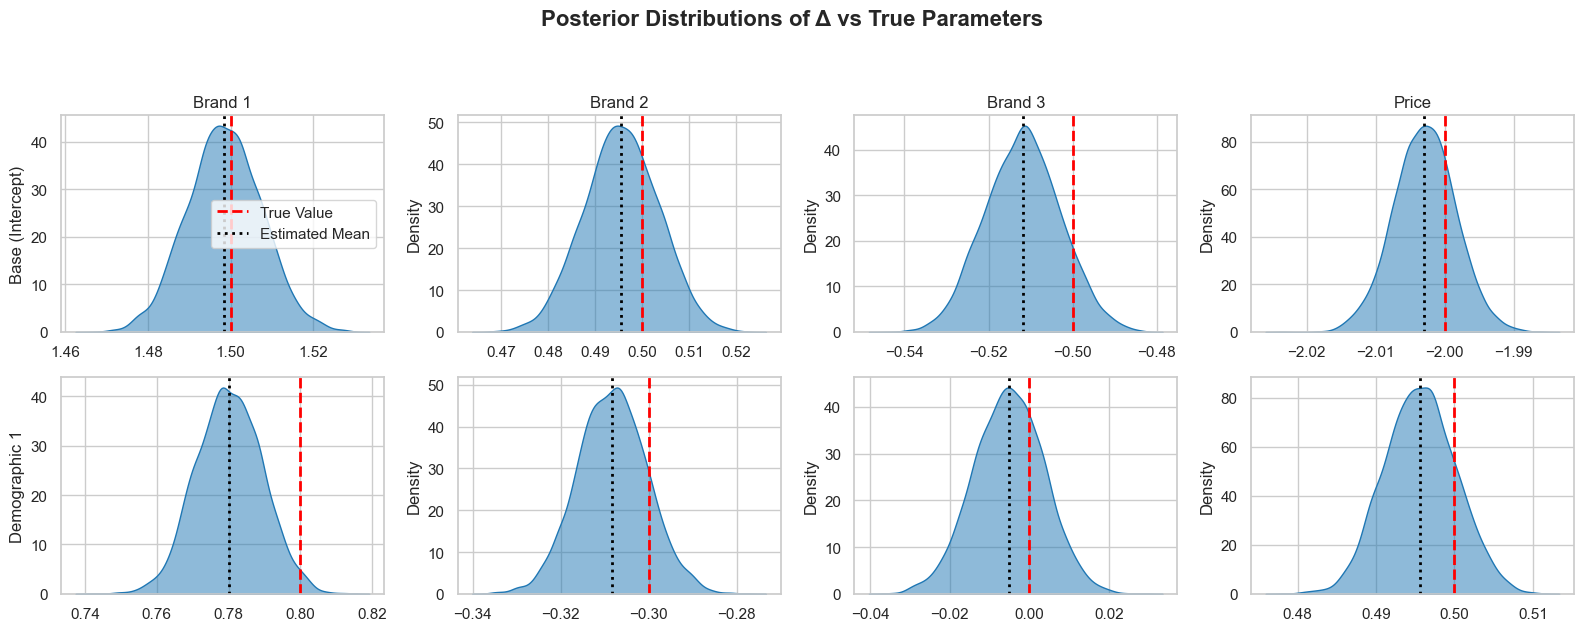

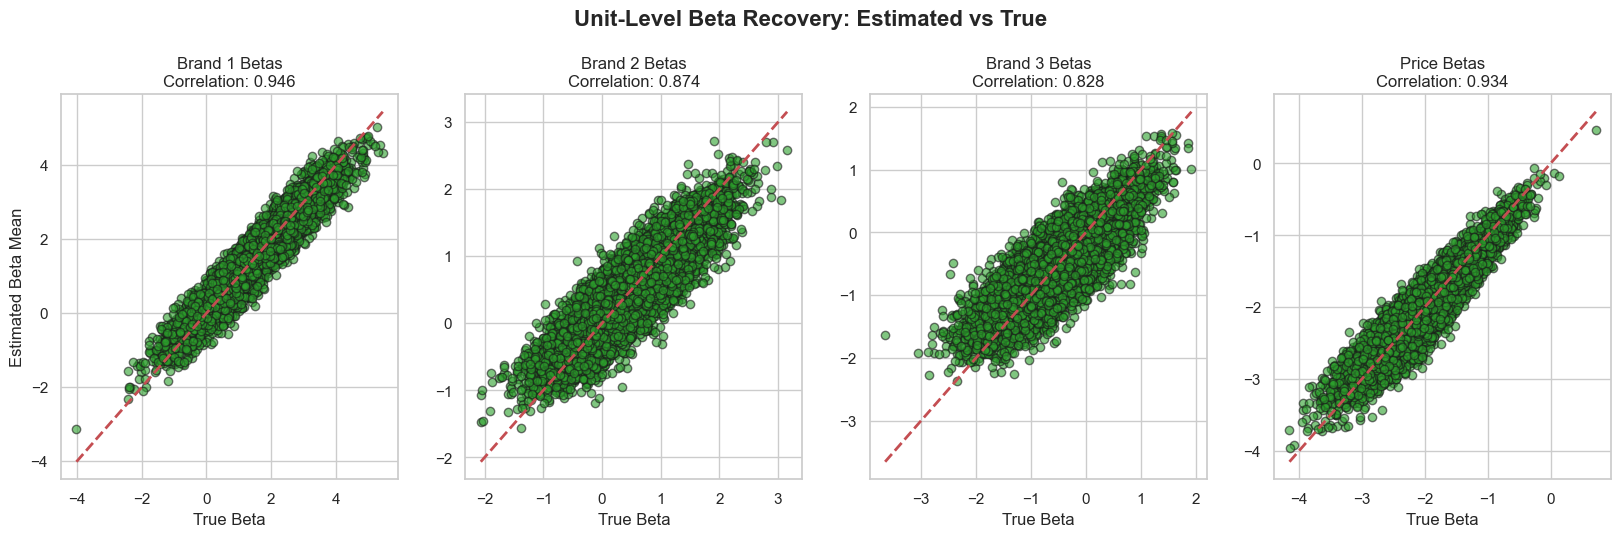

In [21]:
# 1. Reshape Delta samples
k_dim = data_sim["n_params"]
n_demos = data_sim["Z"].shape[1]
n_units = data_sim["n_units"]

delta_draws = samps_sim["Delta"].reshape(-1, n_demos, k_dim)

# 2. Extract Posterior Means
est_delta = np.mean(delta_draws, axis=0)
true_delta = data_sim["TRUE_DELTA"]

# Print numeric comparison
param_labels = ["Brand 1", "Brand 2", "Brand 3", "Price"]
demo_labels = ["Base (Intercept)", "Demographic 1"]

print("=== DELTA PARAMETER RECOVERY ===")
for d in range(n_demos):
    print(f"\n--- {demo_labels[d]} ---")
    df = pd.DataFrame({
        "Parameter": param_labels,
        "True Value": true_delta[d, :],
        "Est. Mean": est_delta[d, :],
        "Difference": np.abs(true_delta[d, :] - est_delta[d, :])
    }).set_index("Parameter")
    display(df.round(3))

# 3. Visual Recovery Plot (Delta Distributions)
fig, axes = plt.subplots(n_demos, k_dim, figsize=(16, 6))

for d in range(n_demos):
    for k in range(k_dim):
        ax = axes[d, k]
        sns.kdeplot(delta_draws[:, d, k], ax=ax, fill=True, color="#1f77b4", alpha=0.5)
        
        # Plot True Value (Red Line)
        ax.axvline(true_delta[d, k], color="red", linestyle="--", linewidth=2, label="True Value")
        # Plot Est Mean (Black Line)
        ax.axvline(est_delta[d, k], color="black", linestyle=":", linewidth=2, label="Estimated Mean")
        
        if d == 0:
            ax.set_title(param_labels[k])
        if k == 0:
            ax.set_ylabel(demo_labels[d])
            
axes[0,0].legend()
plt.suptitle("Posterior Distributions of \u0394 vs True Parameters", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 4. Household Recovery Scatter (Betas)
# FIX: Flatten chains and draws to (-1, units, params) before calculating the mean
beta_draws = samps_sim["beta_i"].reshape(-1, n_units, k_dim)
est_betas = np.mean(beta_draws, axis=0)
true_betas = data_sim["TRUE_BETA"]

fig, axes = plt.subplots(1, k_dim, figsize=(20, 5))
for k in range(k_dim):
    ax = axes[k]
    ax.scatter(true_betas[:, k], est_betas[:, k], alpha=0.6, color="#2ca02c", edgecolor='k')
    
    # 45 degree line
    min_val = min(np.min(true_betas[:, k]), np.min(est_betas[:, k]))
    max_val = max(np.max(true_betas[:, k]), np.max(est_betas[:, k]))
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
    
    corr = np.corrcoef(true_betas[:, k], est_betas[:, k])[0, 1]
    ax.set_title(f"{param_labels[k]} Betas\nCorrelation: {corr:.3f}")
    ax.set_xlabel("True Beta")
    if k == 0: ax.set_ylabel("Estimated Beta Mean")

plt.suptitle("Unit-Level Beta Recovery: Estimated vs True", fontsize=16, fontweight='bold', y=1.05)
plt.show()